# **Phishing Website Detection by Machine Learning Techniques**




## **1. Introduction:**
A phishing website is a common social engineering method that mimics trustful uniform resource locators (URLs) and webpages. The objective of this project is to train machine learning models and deep neural nets on the dataset created to predict phishing websites. Both phishing and benign URLs of websites are gathered to form a dataset and from them required URL and website content-based features are extracted. The performance level of each model is measures and compared.

## Traget Varibales
URL is a field
1. Legitimate (1)
2. Phishing (0)

## **2. Loading Libraries & Data:**

The csv file is uploaded and stored in the dataframe.

In [7]:
#importing basic packages
import os
print(os.listdir())
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

['.ipynb_checkpoints', '1.Benign_list_big_final.csv', '2.online-valid.csv', '3.legitimate.csv', '4.phishing.csv', 'Multilayer Perceptrons.pickle.dat', 'Phishing Website Detection_Models & Training.ipynb', 'PhishingWebsite_model.pickle.dat', 'URL Feature Extraction.ipynb', 'URLFeatureExtraction.py', 'url_dataset.csv', 'XGBoostClassifier.pickle.dat']


In [8]:
#Loading the data
url = pd.read_csv('url_dataset.csv')
url.head(27)

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
5,nypost.com,0,0,1,4,0,0,1,0,0,1,1,1,0,0,1,0,0
6,kienthuc.net.vn,0,0,1,2,0,0,0,0,1,1,1,1,0,0,1,0,0
7,thenextweb.com,0,0,1,6,0,0,0,0,0,1,0,0,0,0,1,0,0
8,tobogo.net,0,0,1,2,0,0,0,0,0,1,0,0,0,0,1,0,0
9,akhbarelyom.com,0,0,1,5,0,0,0,0,0,1,0,1,0,0,1,0,0


## **3. Familiarizing with Data**
### Shape of dataset
In this step, few dataframe methods are used to look into the data and its features.

In [9]:
#Checking the shape of the dataset
url.shape

# conatins 10000 samples and 18 features added the target varibvle

(10000, 18)

In [10]:
#Listing the features of the dataset
url.columns

Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record',
       'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over',
       'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')

In [11]:
#Information about the dataset
# check for any NULL attribute
url.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

In [12]:
# Gneretae a sample random row or column
url.sample(5)

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
9027,liderfmtocos.website.radio.br,0,0,1,7,0,0,0,0,0,0,1,1,1,0,1,0,1
1096,plarium.com,0,0,1,5,0,0,0,0,0,1,0,1,0,0,1,0,0
4808,mirtesen.ru,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
6461,storage.cloud.google.com,0,1,1,2,0,0,1,0,0,1,1,1,0,0,1,0,1
4920,sourceforge.net,0,0,1,3,0,0,0,0,1,1,1,1,0,0,1,0,0


In [13]:
unique_values_domain = url['Domain'].value_counts()
print("Unique values and their counts for 'Domain':")
print(unique_values_domain)

Unique values and their counts for 'Domain':
Domain
torcache.net                         197
thenextweb.com                       142
distractify.com                      131
extratorrent.cc                      122
twitter.com                          121
                                    ... 
harrisonk12msus-my.sharepoint.com      1
amazon.co.jp.lcmgo.com                 1
leadershipauthoritypro.com             1
keepsolution.com                       1
info.lionnets.com                      1
Name: count, Length: 3553, dtype: int64


In [14]:
for column in url.columns:
    if url[column].dtype == 'int64':   
        unique_values = url[column].unique()
        print(f"Unique values for '{column}':")
        print(unique_values)


Unique values for 'Have_IP':
[0 1]
Unique values for 'Have_At':
[0 1]
Unique values for 'URL_Length':
[1 0]
Unique values for 'URL_Depth':
[ 1  3  4  2  6  5  7 10  9 14  8  0 18 17 13 11 12 20]
Unique values for 'Redirection':
[0 1]
Unique values for 'https_Domain':
[0 1]
Unique values for 'TinyURL':
[0 1]
Unique values for 'Prefix/Suffix':
[0 1]
Unique values for 'DNS_Record':
[0 1]
Unique values for 'Web_Traffic':
[1 0]
Unique values for 'Domain_Age':
[1 0]
Unique values for 'Domain_End':
[1 0]
Unique values for 'iFrame':
[0 1]
Unique values for 'Mouse_Over':
[0 1]
Unique values for 'Right_Click':
[1 0]
Unique values for 'Web_Forwards':
[0 1]
Unique values for 'Label':
[0 1]


## Change name of Target varibale 'Label'

In [15]:
url = url.rename(columns={'Label': 'Target'})
url.sample(5)

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Target
6409,stolizaparketa.ru,0,1,1,7,0,0,0,0,0,1,0,1,0,0,1,0,1
3902,censor.net.ua,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
2987,tunein.com,0,0,1,5,0,0,0,0,0,1,0,1,0,0,1,1,0
2170,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
5053,zcvalkenburg.nl,0,0,0,1,0,0,0,0,1,0,1,1,0,0,1,0,1


## Univeriate Analysis

In [16]:
# idenitfy uniquew no of values
print("Total target varibales")
print(len(url.Target.unique()))

Total target varibales
2


In [17]:
# Looking at unique values
url["Target"].unique()

array([0, 1], dtype=int64)

#### It states that If the target variable is 
#### 1 : URL is of legitimate site
#### 0 : URL is of Fake website

#### Frequency Distribution of target variable


In [18]:
url.groupby("Target").size()

Target
0    5000
1    5000
dtype: int64

## **4. Visualizing the data**
Few plots and graphs are displayed to find how the data is distributed and the how features are related to each other.

### Visualizing Frequency Distribution

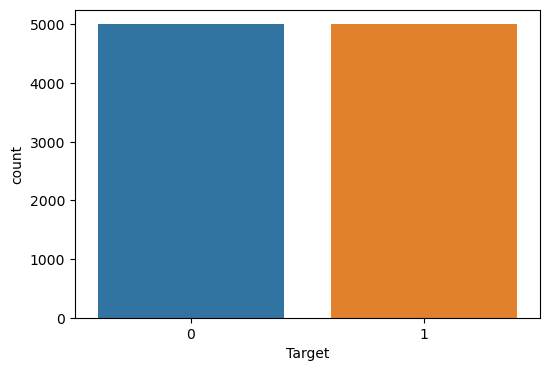

In [19]:
f, ax = plt.subplots(figsize=(6, 4))
ax = sns.countplot(x="Target", data=url)
plt.show()

### w.r.t to specific features

In [20]:
url.groupby('Domain_Age')['Target'].value_counts()

Domain_Age  Target
0           1         3141
            0         2722
1           0         2278
            1         1859
Name: count, dtype: int64

### visualize 

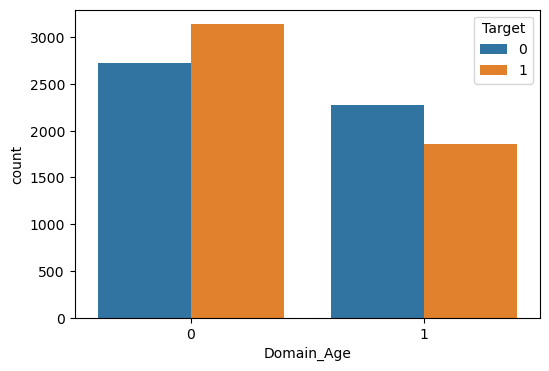

In [21]:
f, ax = plt.subplots(figsize=(6, 4))
ax = sns.countplot(x="Domain_Age", hue='Target', data=url)
plt.show()

### *To see data w.r.t graphs*

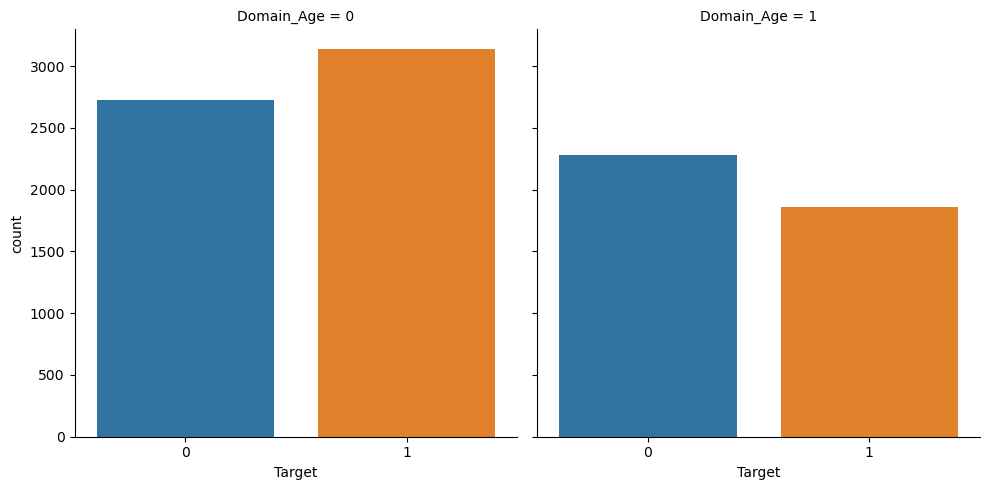

In [22]:
ax= sns.catplot(x='Target', col='Domain_Age', data=url, kind='count')

## Description 
    To find out the univeriate analysis from the above data

### Statisctics of data
Note: If there is any NULL value, then remove it by cheking Count.

In [23]:
# Data description in seconds
    # It will give the statistics of all properties of a dataset
url.describe()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000
mean,0.005500,0.022600,0.773400,3.072000,0.013500,0.000200,0.090300,0.093200,0.100800,0.845700,0.413700,0.8099,0.090900,0.06660,0.99930,0.105300,0.500000
std,0.073961,0.148632,0.418653,2.128631,0.115408,0.014141,0.286625,0.290727,0.301079,0.361254,0.492521,0.3924,0.287481,0.24934,0.02645,0.306955,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.500000
75%,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0000,0.000000,0.00000,1.00000,0.000000,1.000000
max,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.00000,1.00000,1.000000,1.000000


### Understanding columns data from a closer prepective

In [24]:
info = ["Domain","1: Yes, 0: No"]
for i in range(len(info)):
    print(url.columns[i]+":\t\t\t"+info[i])

Domain:			Domain
Have_IP:			1: Yes, 0: No


### Class Label or Target Variable
#### Analyze Target Variable

In [25]:
# Use describe on specific attriuet to specifically analyze it
url["Target"]. describe()

count    10000.000000
mean         0.500000
std          0.500025
min          0.000000
25%          0.000000
50%          0.500000
75%          1.000000
max          1.000000
Name: Target, dtype: float64

## Bivariate Analysis
#### [ typically refers to the analysis of two variables to understand the relationship between them]
    performed to find the relationship between each variable in the dataset and the target variable of interest (or) using 2 variables and finding the relationship between them.
    
### Operations to perform in Bivariate Analysis
#### 1. Correlation Analysis

### 1. Correlation Analysis
-    Calculate the correlation coefficient between pairs of variables/ Features.(between Columns)
-    This helps understand the linear relationship between features.(How columns are correlated with each other) 
-    The correlation coefficient ranges from -1 to 1, indicating negative to positive correlation. (Show strength of correlation)
Note: Positive values indicate a positive correlation, negative values indicate a negative correlation, and values close to zero indicate a weak correlation.

- #### Correlation Matrix
Computes the pairwise correlation matrix for all numeric variables in the dataset.

In [26]:
# exclude any non numeric field to observe correlation
numeric_columns = url.select_dtypes(include=['int64']).columns
corr_matrix = url[numeric_columns].corr()
print(corr_matrix)

                Have_IP   Have_At  URL_Length  URL_Depth  Redirection  \
Have_IP        1.000000 -0.011308   -0.076021  -0.030466    -0.008700   
Have_At       -0.011308  1.000000    0.067844   0.029944    -0.000297   
URL_Length    -0.076021  0.067844    1.000000   0.439378     0.038482   
URL_Depth     -0.030466  0.029944    0.439378   1.000000    -0.040189   
Redirection   -0.008700 -0.000297    0.038482  -0.040189     1.000000   
https_Domain  -0.001052 -0.002151    0.007656  -0.000478    -0.001655   
TinyURL       -0.023430  0.067122   -0.005318   0.010980     0.026634   
Prefix/Suffix -0.023841  0.018369   -0.146102  -0.114919    -0.025581   
DNS_Record    -0.011425  0.025073   -0.019508  -0.086073    -0.027654   
Web_Traffic    0.024279 -0.017002    0.063717   0.075315     0.018784   
Domain_Age     0.047349 -0.017072    0.071029  -0.070101     0.012581   
Domain_End     0.018799  0.001651    0.028755  -0.061798     0.025758   
iFrame        -0.004701 -0.008294   -0.039903  -0.0

#### Visualize the correlation matrix using a heatmap

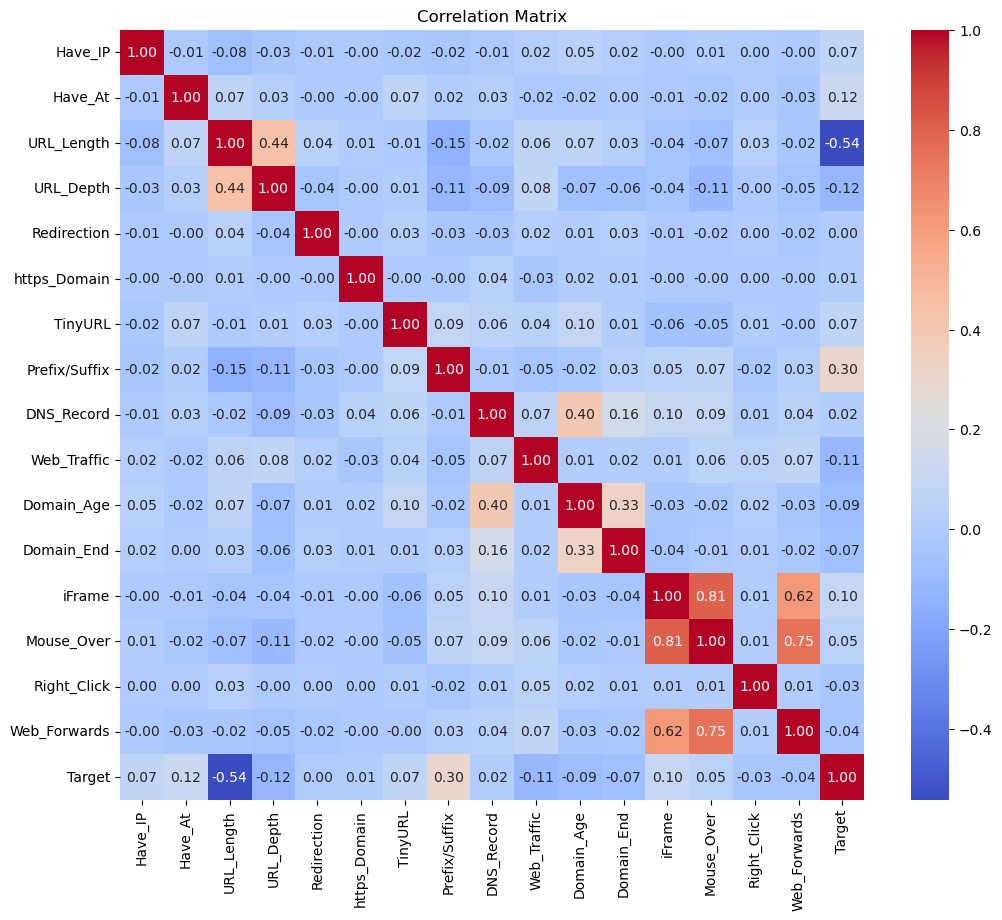

In [27]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

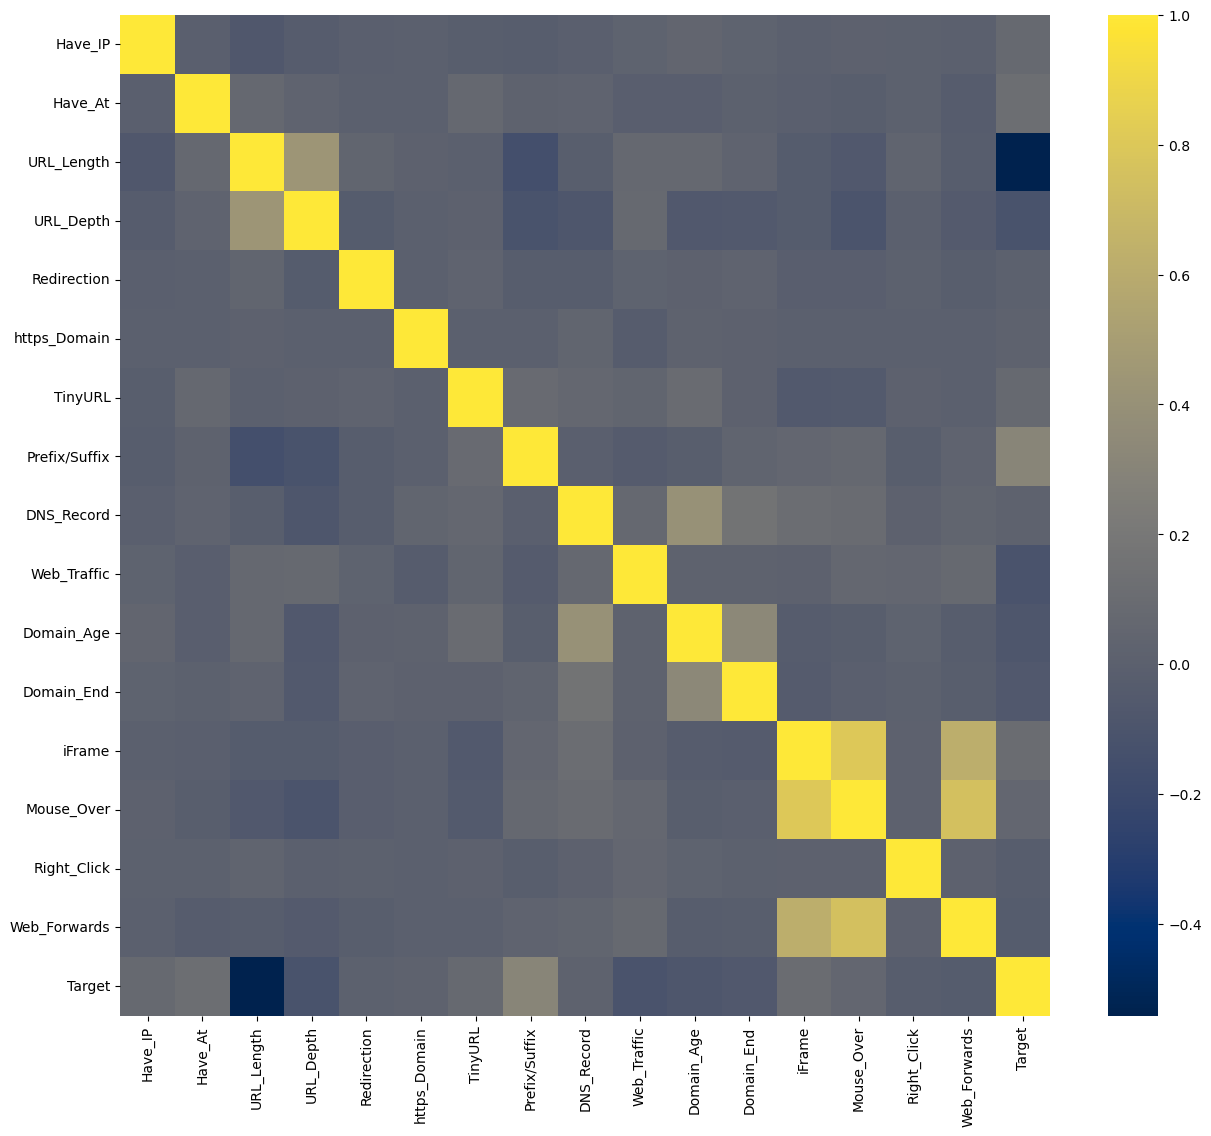

In [28]:
#Correlation heatmap without values
numeric_columns = url.select_dtypes(include=['number'])

# Correlation heatmap without values
# plasma,cividis , viridis, magma, inferno(by default)
plt.figure(figsize=(15, 13))
sns.heatmap(numeric_columns.corr(), cmap='cividis')
plt.show()

- #### Correlation with target variable
Calculates the correlation between each feature and the target variable

In [29]:
target_corr = corr_matrix['Target'].sort_values(ascending=False)
print(target_corr)

Target           1.000000
Prefix/Suffix    0.302705
Have_At          0.118419
iFrame           0.098446
Have_IP          0.074367
TinyURL          0.072921
Mouse_Over       0.051338
DNS_Record       0.015943
https_Domain     0.014144
Redirection      0.002600
Right_Click     -0.026467
Web_Forwards    -0.041376
Domain_End      -0.068556
Domain_Age      -0.085077
Web_Traffic     -0.108793
URL_Depth       -0.119707
URL_Length      -0.541287
Name: Target, dtype: float64


#### Now as i already know that there are 2 unique values for all these varibles expect for URL_Depth
##### We will look for:
- count of each unique value fro some attributes for analysis              **[value_counts()]**
- ALso visualize each count analysis       **[countplot()]**

In [30]:
# count
url["Prefix/Suffix"].value_counts()

Prefix/Suffix
0    9068
1     932
Name: count, dtype: int64

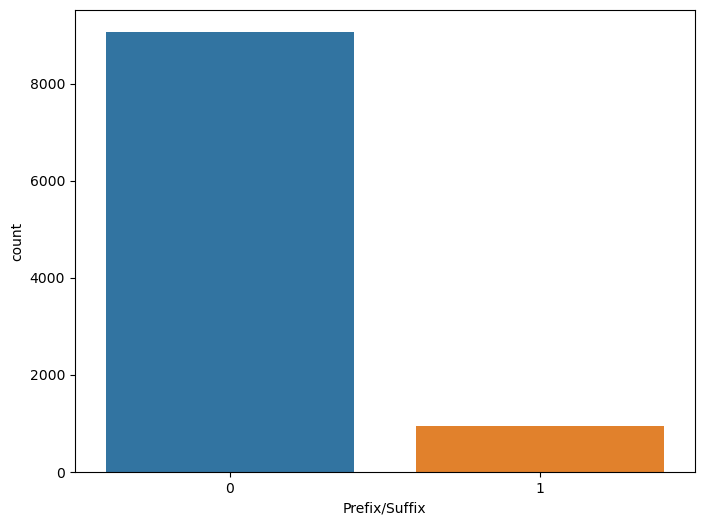

In [31]:
# Visualization
f, ax = plt.subplots(figsize=(8,6))
ax = sns.countplot(x="Prefix/Suffix", data=url)
plt.show()

In [32]:
# count
url["Have_At"].value_counts()

Have_At
0    9774
1     226
Name: count, dtype: int64

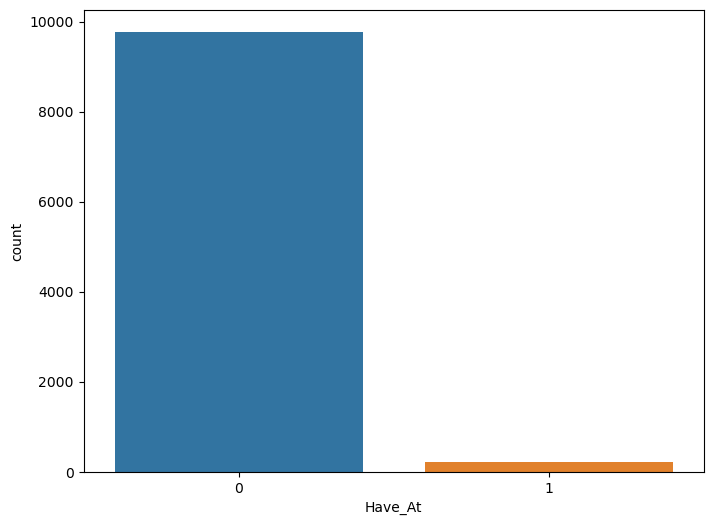

In [33]:
# Visualization
f, ax = plt.subplots(figsize=(8,6))
ax = sns.countplot(x="Have_At", data=url)
plt.show()

In [34]:
url["URL_Depth"].value_counts()

URL_Depth
2     2298
3     1909
1     1608
4     1384
5      963
0      689
6      486
7      306
10     146
8      128
9       49
14      17
11       8
12       4
13       2
18       1
17       1
20       1
Name: count, dtype: int64

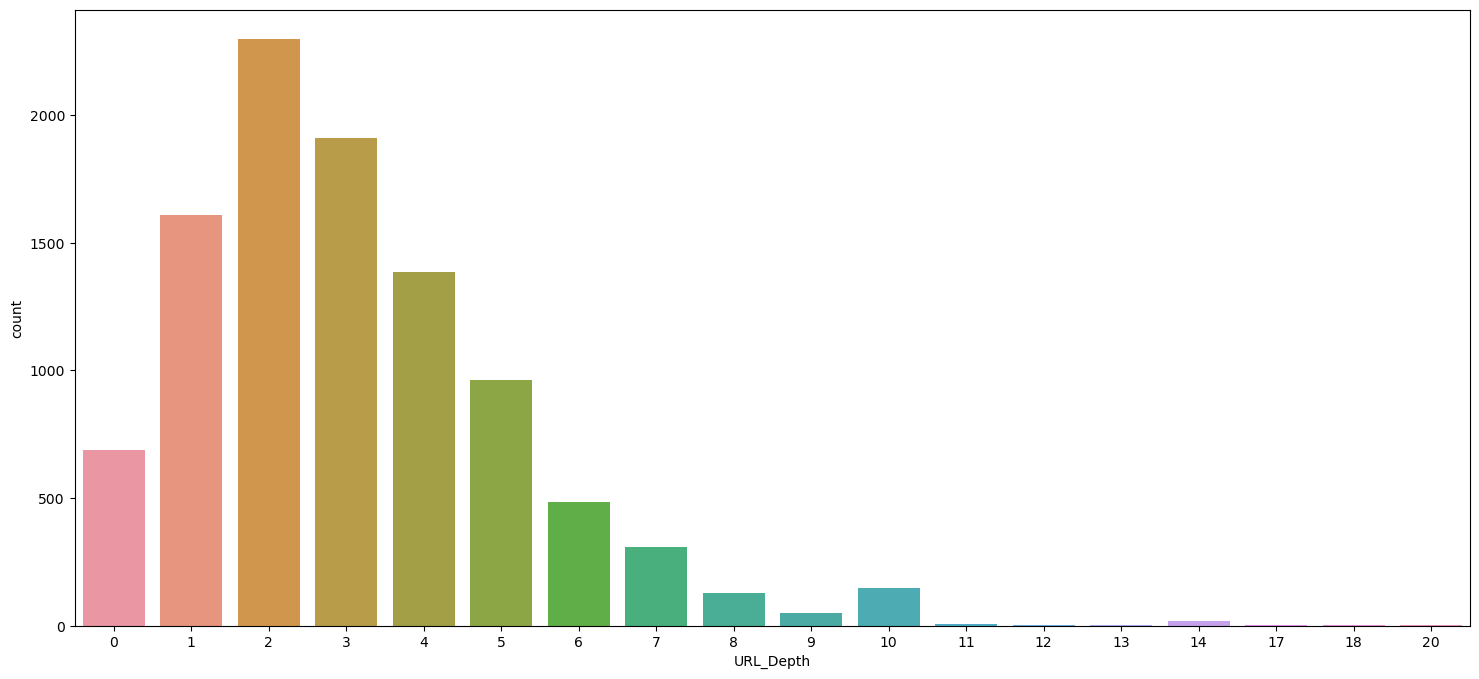

In [35]:
# Visualization
f, ax = plt.subplots(figsize=(18,8))
ax = sns.countplot(x="URL_Depth", data=url)
plt.show()

#### To see the frequency distribution of target variable w.r.t some other variable . Why with only URL_Depth?
Becasue it has multiple values.

- Frequency distribution of target variable w.r.t to specific varibale            **[groupby(var)[target].value_counts()]**
- Visualize frequency Distribution       **[hue="Target"]**

In [36]:
url.groupby("URL_Depth")["Target"].value_counts()

URL_Depth  Target
0          1          675
           0           14
1          1          978
           0          630
2          0         1298
           1         1000
3          0         1204
           1          705
4          0          923
           1          461
5          1          593
           0          370
6          0          243
           1          243
7          1          176
           0          130
8          1           95
           0           33
9          1           38
           0           11
10         0          125
           1           21
11         1            8
12         1            4
13         1            2
14         0           17
17         0            1
18         0            1
20         1            1
Name: count, dtype: int64

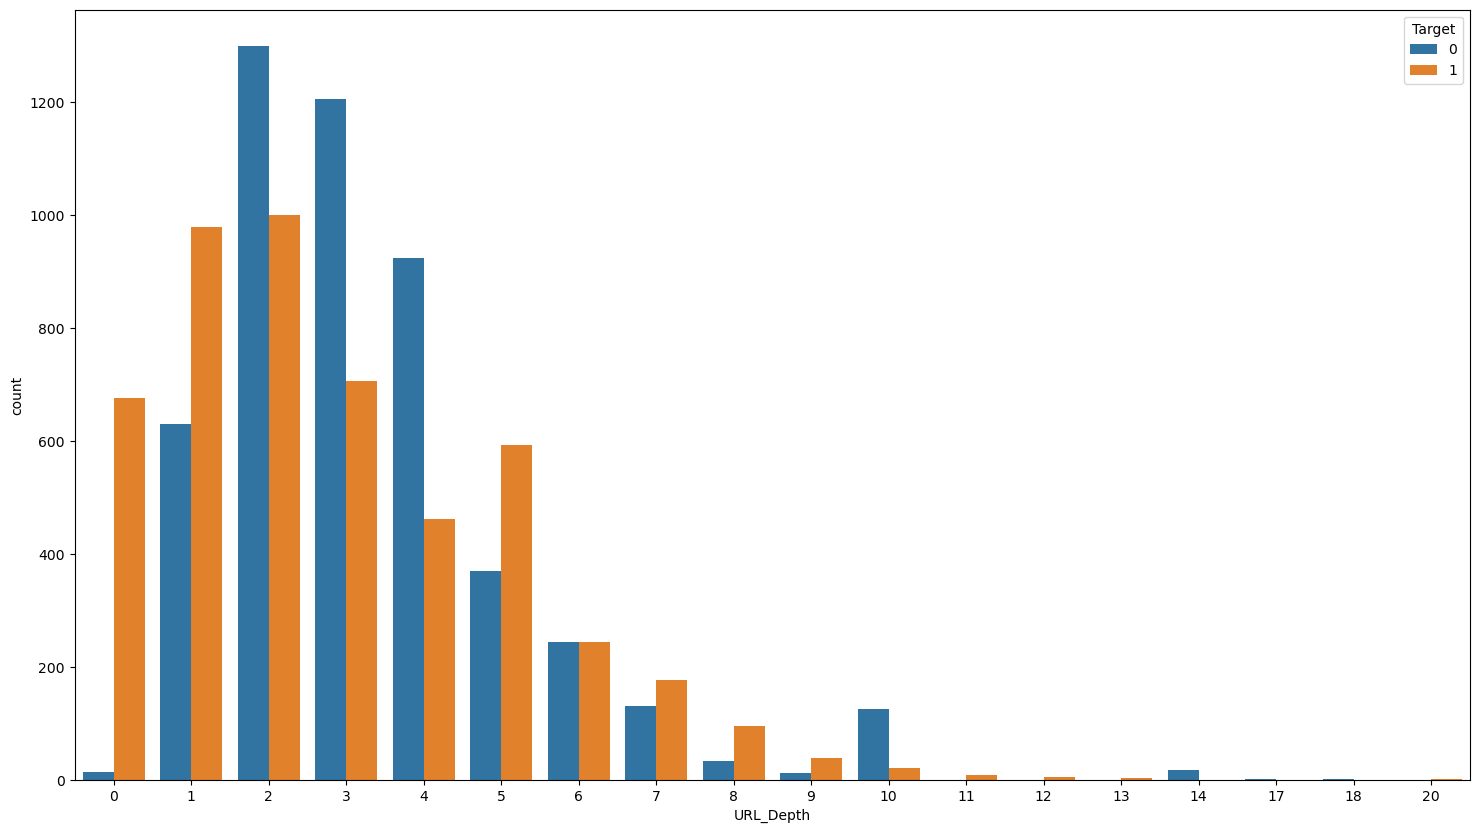

In [37]:
f, ax = plt.subplots(figsize=(18,10))
ax = sns.countplot(x="URL_Depth", hue="Target", data=url)
plt.show()

- #### Correlation Thresholding
To filter correlations based on a threshold, showing only those above a certain value.

In [38]:
threshold = 0.5  # Adjusting the threshold as needed
high_corr = corr_matrix[abs(corr_matrix) > threshold]
print(high_corr)


               Have_IP  Have_At  URL_Length  URL_Depth  Redirection  \
Have_IP            1.0      NaN         NaN        NaN          NaN   
Have_At            NaN      1.0         NaN        NaN          NaN   
URL_Length         NaN      NaN    1.000000        NaN          NaN   
URL_Depth          NaN      NaN         NaN        1.0          NaN   
Redirection        NaN      NaN         NaN        NaN          1.0   
https_Domain       NaN      NaN         NaN        NaN          NaN   
TinyURL            NaN      NaN         NaN        NaN          NaN   
Prefix/Suffix      NaN      NaN         NaN        NaN          NaN   
DNS_Record         NaN      NaN         NaN        NaN          NaN   
Web_Traffic        NaN      NaN         NaN        NaN          NaN   
Domain_Age         NaN      NaN         NaN        NaN          NaN   
Domain_End         NaN      NaN         NaN        NaN          NaN   
iFrame             NaN      NaN         NaN        NaN          NaN   
Mouse_

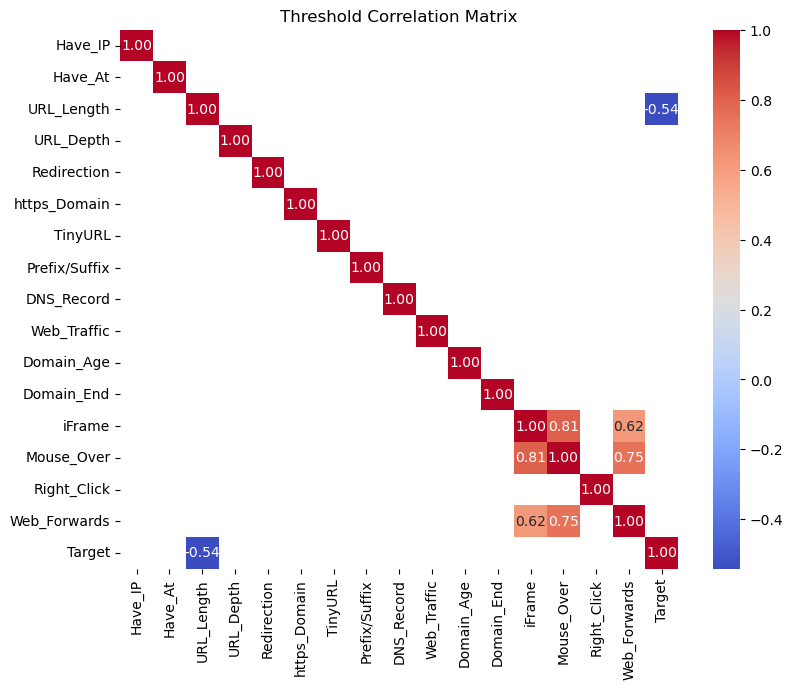

In [39]:
# HeatMap
plt.figure(figsize=(9, 7))
sns.heatmap(high_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Threshold Correlation Matrix')
plt.show()

### Conclusion of Correlation
- **Strongest Positive Correlation:**
    Prefix/Suffix: 0.302705
    
    presence of prefixes or suffixes might be indicative of phishing behavior.

- **Weakest Positive Correlation:**
    Redirection: 0.002600
    
    presence of redirection in URLs is not strongly indicative of phishing behavior.

- **Weakest Negative Correlation:**
    Right_Click: -0.026467
    
    ability to right-click on a website, while not a strong indicator, is somewhat associated with legitimate websites.

- **Strongest Negative Correlation:**
    URL_Length: -0.541287
     
     length of the URL is a more significant factor in distinguishing between phishing and legitimate websites.
    



### 2.Data Distribution

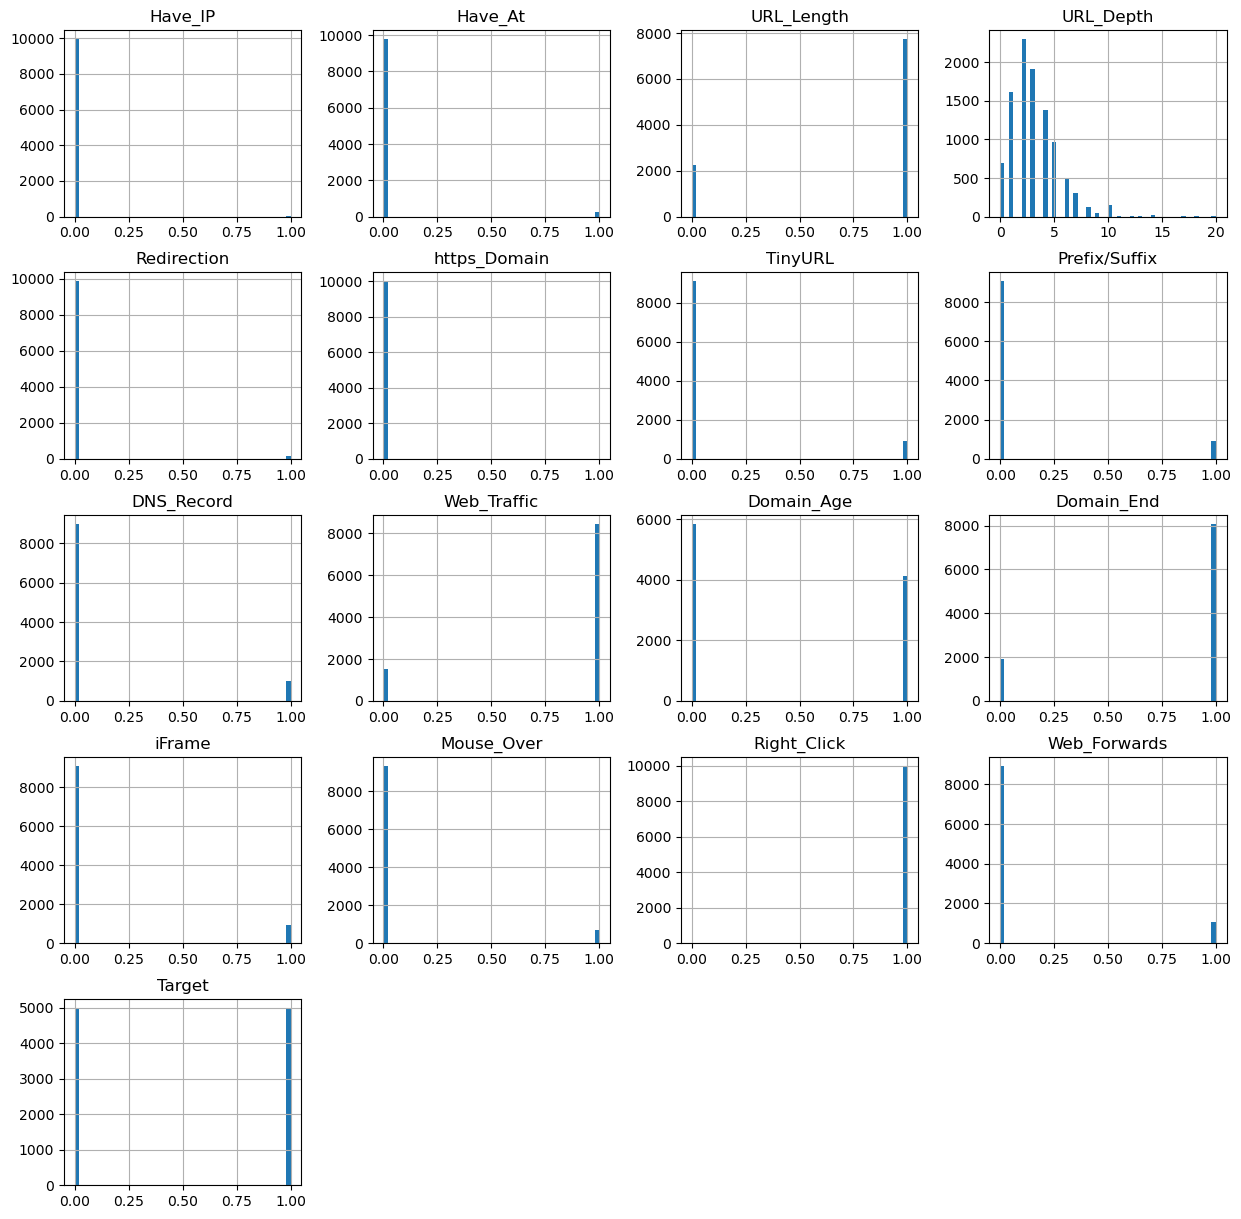

In [40]:
#Plotting Histogram
url.hist(bins = 50,figsize = (15,15))
plt.show()

#### Anayze Shapes of Histogram using Kernel Density Estimate

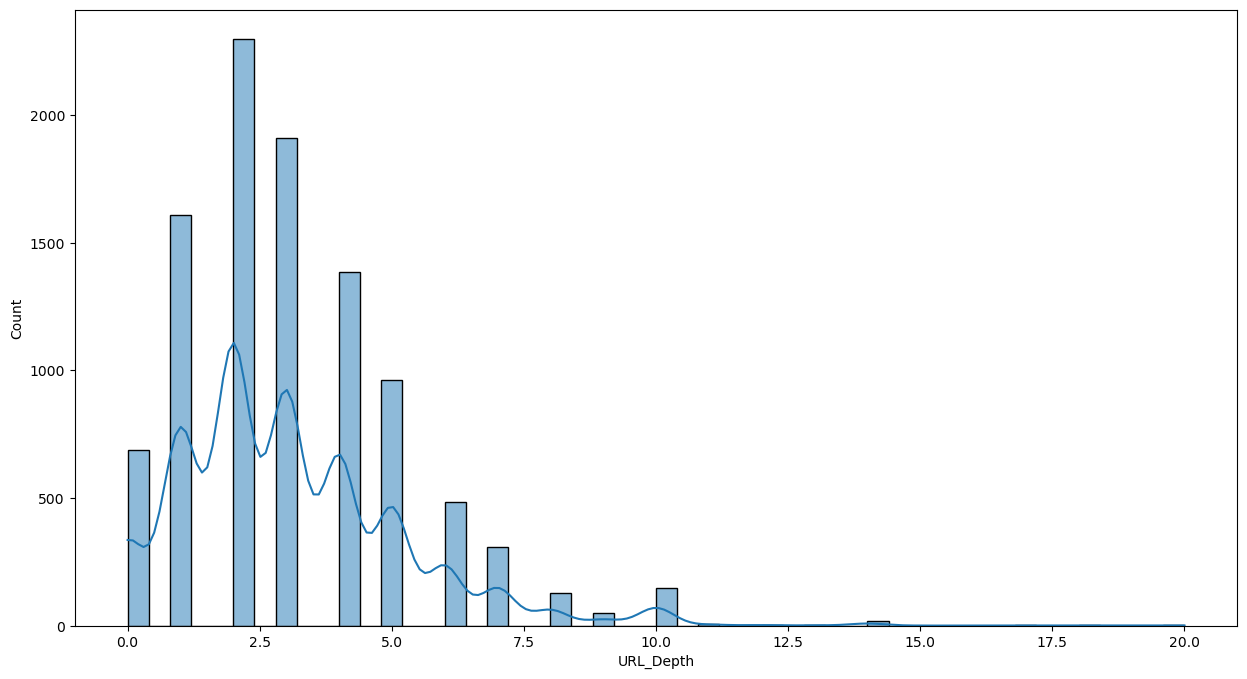

In [41]:
# Plotting the data distribution with KDE

# For URL_Depth
plt.figure(figsize=(15, 8))
sns.histplot(data=url, x='URL_Depth', bins=50, kde=True)
plt.show()

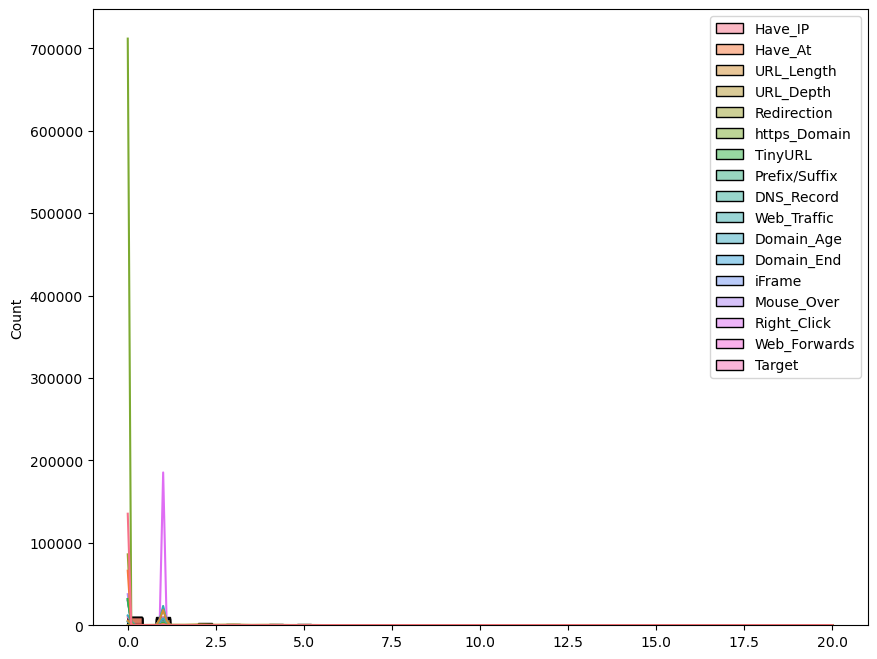

In [42]:
# For all features
plt.figure(figsize=(10, 8))

sns.histplot(data=url,bins = 50, kde=True)
plt.show()

## Multivariate Analysis
- involves the simultaneous analysis of multiple variables in a dataset to understand the relationships, patterns, and interactions among them.
- The goal is to gain insights into complex systems and identify underlying structures.

In [43]:
# Lets see Taret value by percentage
print("Legitimate: ",len(url[url.Target == 1]))
print("Fake: ",len(url[url.Target == 0]))

# Direct
print(url['Target'].value_counts(normalize=True) * 100)

Legitimate:  5000
Fake:  5000
Target
0    50.0
1    50.0
Name: proportion, dtype: float64


### Analyzing Features one by one

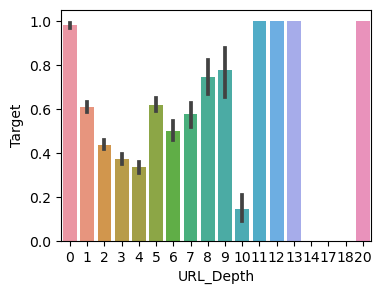

In [44]:
plt.figure(figsize=(4, 3))
sns.barplot(x=url["URL_Depth"], y=url["Target"])
plt.show()

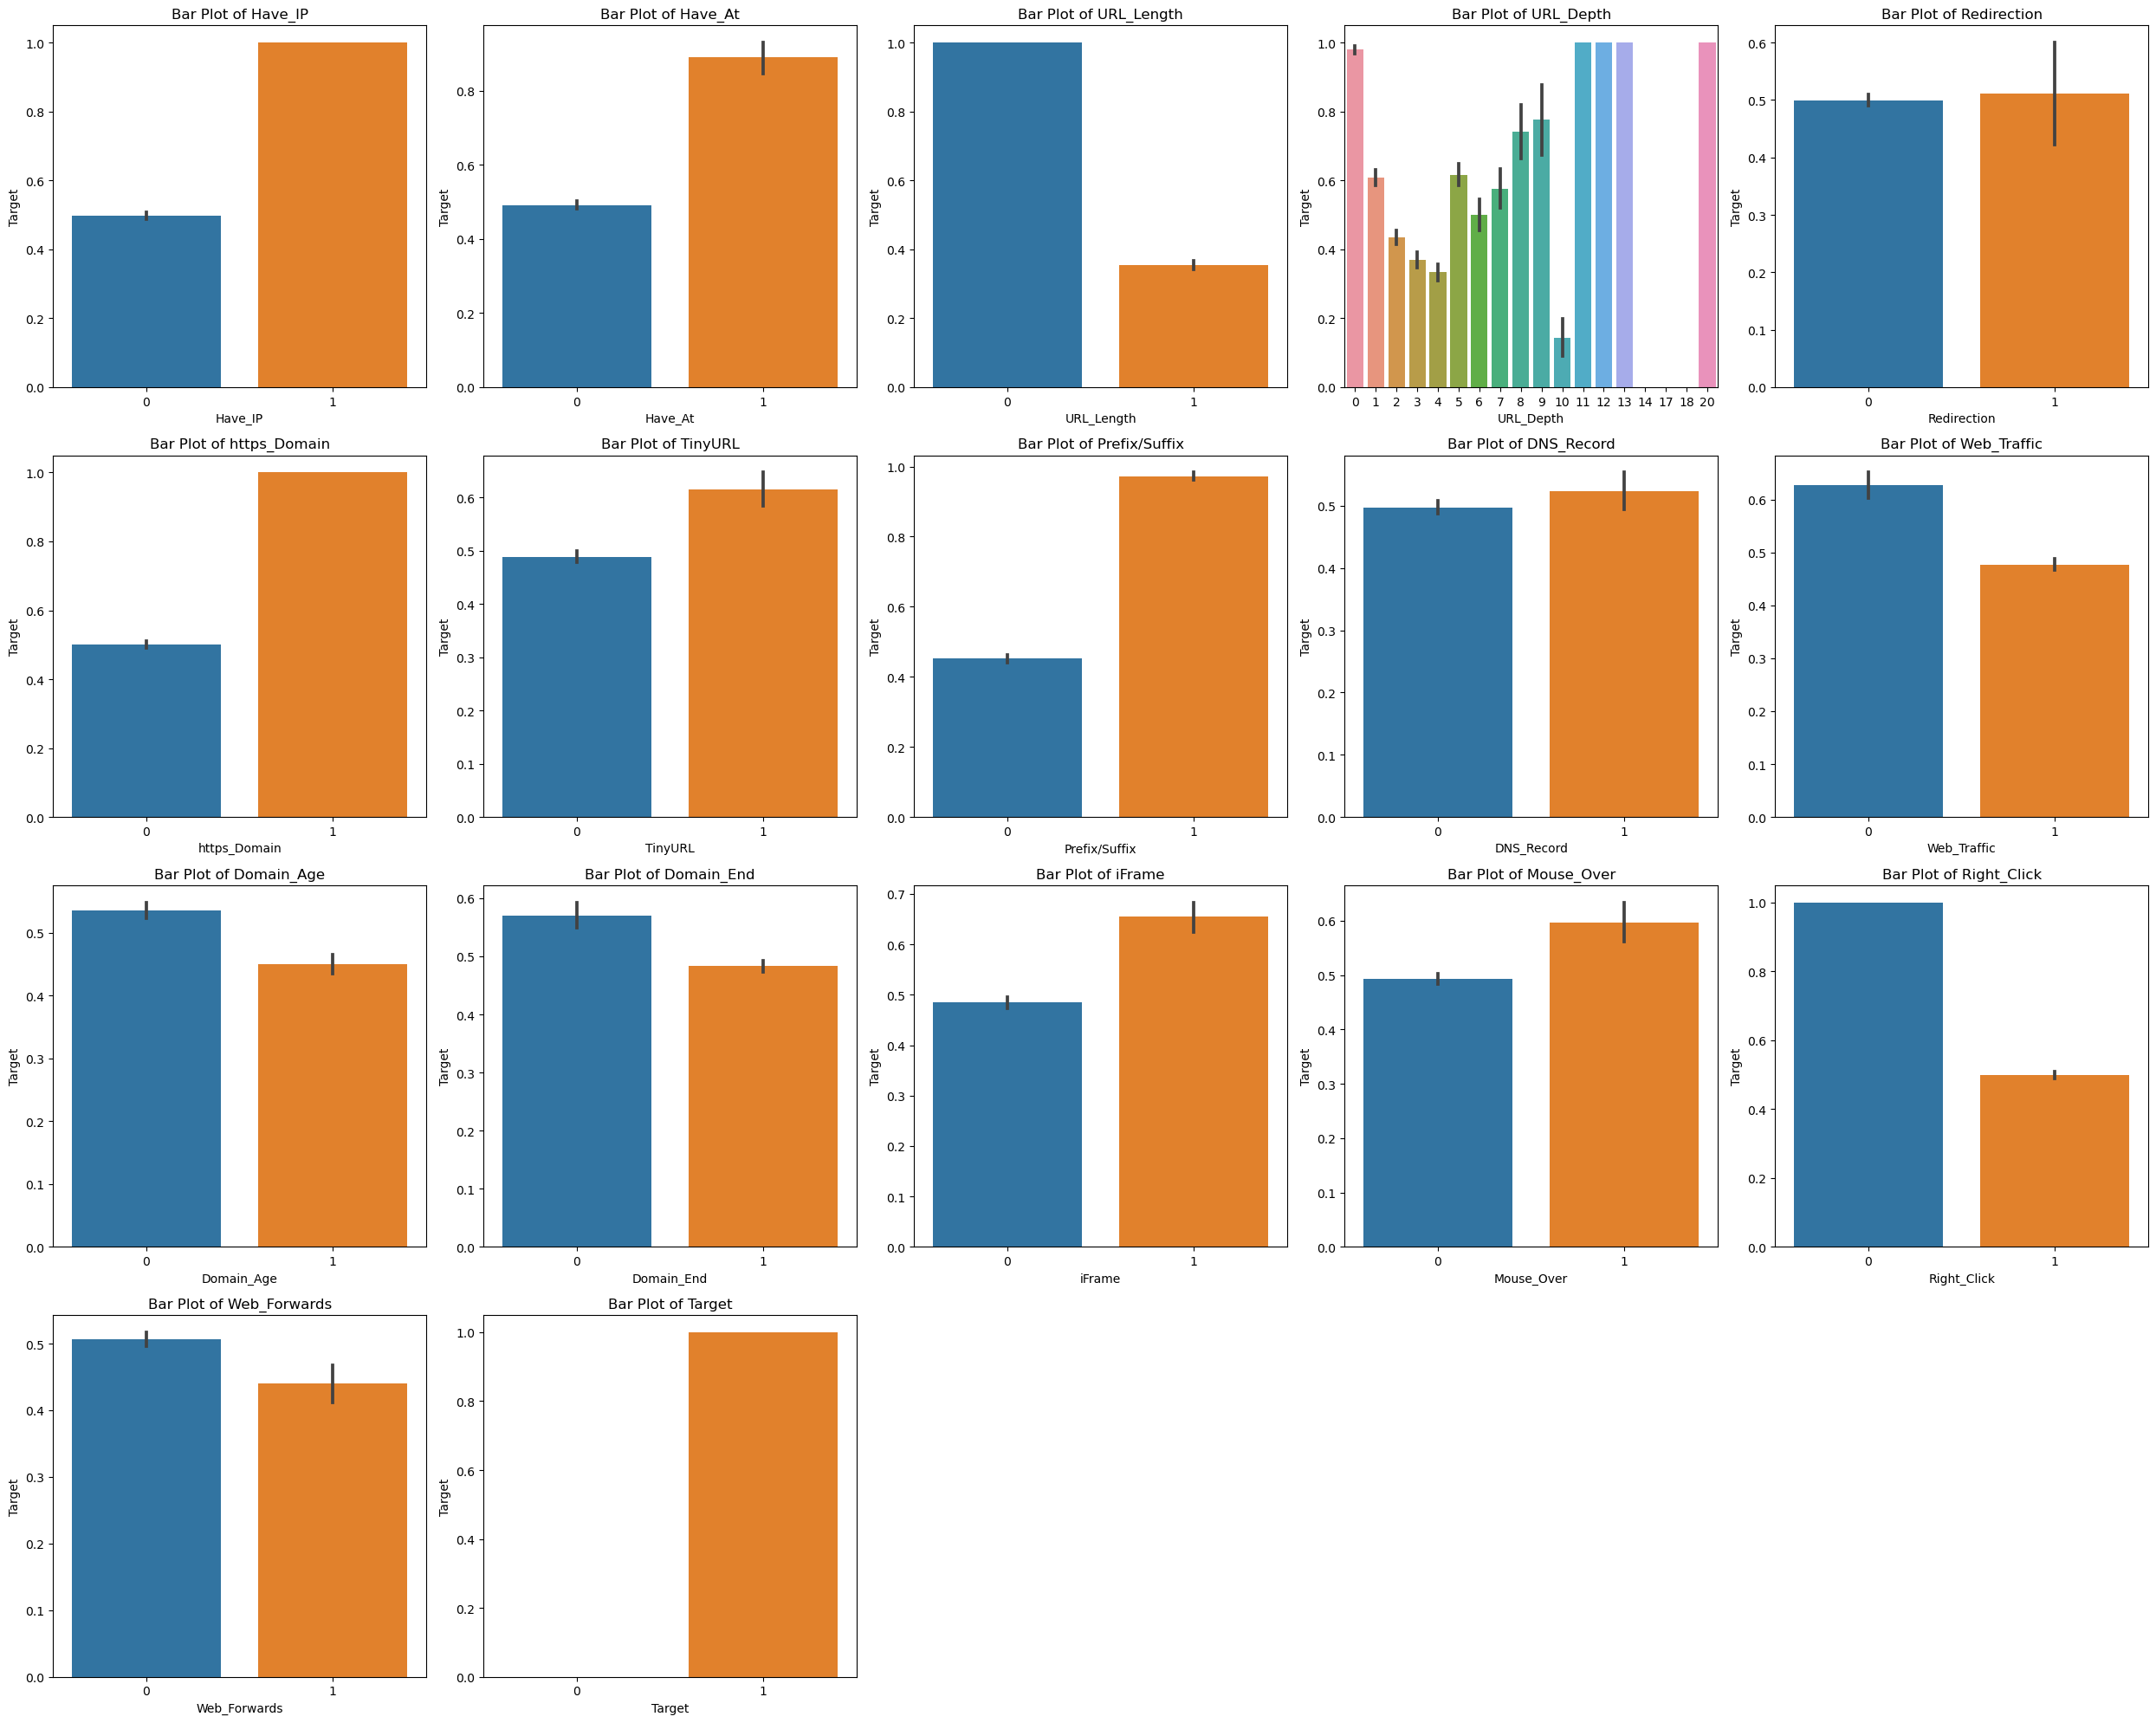

In [45]:
numeric_columns = url.select_dtypes(include=['int64']).columns

plt.figure(figsize=(25, 20))
for i, column in enumerate(numeric_columns):
    plt.subplot(4, 5, i + 1)  # Adjust the subplot layout based on the number of variables
    sns.barplot(x=column, data=url, y="Target")
    plt.title(f'Bar Plot of {column}')

plt.tight_layout()
plt.show()

<Axes: xlabel='URL_Depth', ylabel='Density'>

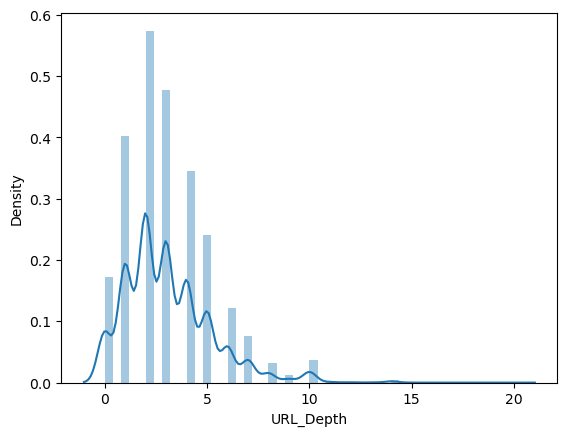

In [46]:
sns.distplot(url["URL_Depth"])

## **5. Data Preprocessing & EDA**
Here, we clean the data by applying data preprocesssing techniques and transform the data to use it in the models.

In [47]:
url.describe()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000
mean,0.005500,0.022600,0.773400,3.072000,0.013500,0.000200,0.090300,0.093200,0.100800,0.845700,0.413700,0.8099,0.090900,0.06660,0.99930,0.105300,0.500000
std,0.073961,0.148632,0.418653,2.128631,0.115408,0.014141,0.286625,0.290727,0.301079,0.361254,0.492521,0.3924,0.287481,0.24934,0.02645,0.306955,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.500000
75%,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0000,0.000000,0.00000,1.00000,0.000000,1.000000
max,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.00000,1.00000,1.000000,1.000000


#### Analysis
The above obtained result shows that the most of the data is made of 0's & 1's except 'Domain' & 'URL_Depth' columns. The Domain column doesnt have any significance to the machine learning model training. So dropping the *'Domain'* column from the dataset. 

### Dropping the non-numeric Column

In [48]:
#Dropping the Domain column
data = url.drop(['Domain'], axis = 1).copy()

In [49]:
data.head(4)

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Target
0,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


This leaves us with 16 features & a target column. The *'URL_Depth'* maximum value is 20. According to my understanding, there is no necessity to change this column.


### Checking for any null or missing values

In [50]:
#checking the data for null or missing values
data.isnull().sum()

Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Target           0
dtype: int64

In the feature extraction file, the extracted features of legitmate & phishing url datasets are just concatenated without any shuffling. This resulted in top 5000 rows of legitimate url data & bottom 5000 of phishing url data. 

To even out the distribution while splitting the data into training & testing sets, we need to shuffle it. This even evades the case of overfitting while model training.

### shuffling the rows 
in the dataset so that when splitting the train and test set are equally distributed


In [51]:
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Target
0,0,0,1,2,0,0,0,0,0,1,0,1,0,0,1,0,0
1,0,0,1,3,0,0,0,0,1,1,1,1,0,0,1,0,0
2,0,0,1,5,0,0,0,0,0,0,0,0,0,0,1,0,1
3,0,0,1,2,0,0,0,0,0,1,0,1,0,0,1,0,0
4,0,0,1,3,0,0,0,0,0,1,0,1,1,1,1,1,1


From the above execution, it is clear that the data doesnot have any missing values.

By this, the data is throughly preprocessed & is ready for training.

## **6. Splitting the Data**

In [52]:
# Sepratating & assigning features and target columns to X & y
from sklearn.model_selection import train_test_split

features = data.drop('Target',axis=1) # drop target feature and store remaing in feature
target = data['Target']               # will store target feature
features.shape, target.shape

((10000, 16), (10000,))

##### Encode Categorical Variables


In [53]:
# Assuming 'Domain' is a categorical variable
# X_encoded = pd.get_dummies(X, columns=['Domain'])

In [54]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(features, target, 
                                                    test_size = 0.2, random_state = 12)
x_train.shape, x_test.shape, y_train.shape,y_test.shape

((8000, 16), (2000, 16), (8000,), (2000,))

### Summarizing the Train Test Set
Data is splitted into 4 sets
- For training
    - X-train (Sample and features)
    - Y-Train (Target)
- For Testing
    - X-Test (Sample and features)
    - Y-Test (Target)
   

In [55]:
print("X-Train: "+str(x_train.shape))
print("Y-Train: "+str(y_train.shape))
print("X-Test: "+str(x_test.shape))
print("Y-Test: "+str(y_test.shape))

X-Train: (8000, 16)
Y-Train: (8000,)
X-Test: (2000, 16)
Y-Test: (2000,)


## **7. Machine Learning Models & Training**

From the dataset above, it is clear that this is a supervised machine learning task. There are two major types of supervised machine learning problems, called classification and regression. 

This data set comes under classification problem, as the input URL is classified as phishing (1) or legitimate (0). The supervised machine learning models (classification) considered to train the dataset in this notebook are:
* Decision Tree
* Random Forest
* Multilayer Perceptrons
* XGBoost
* Autoencoder Neural Network
* Support Vector Machines

In [56]:
#importing packages
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc  
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

In [102]:
# Creating holders to store the model performance results
ML_Model = []      # List to store model names
acc_train = []     # List to store training set accuracies
acc_test = []      # List to store testing set accuracies

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)             # Append the model name to the list
  acc_train.append(round(a, 3))      # Append the rounded training accuracy to the list
  acc_test.append(round(b, 3))       # Append the rounded testing accuracy to the list

### 7.0 Logistic Regression

- #### Model Fitting

In [103]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)
Y_pred_lr = lr.predict(x_test)

In [104]:
Y_pred_lr.shape

(2000,)

- #### Accuracy Check

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Calculate accuracy on the training set
acc_train_lr = accuracy_score(y_train, lr.predict(x_train))

# Calculate accuracy on the testing set
acc_test_lr = accuracy_score(y_test, Y_pred_lr)

In [106]:
#computing the accuracy of the model performance
print("Linear Regression: Accuracy on training Data: {:.1f}".format(acc_train_lr*100))
print("Linear Regression: Accuracy on training Data: {:.1f}".format(acc_train_lr*100))

Linear Regression: Accuracy on training Data: 80.6
Linear Regression: Accuracy on training Data: 80.6


- #### Store Results

In [107]:
storeResults('Linear Regression', acc_train_lr, acc_test_lr)

- #### Confusion Matrix and Classification Report

In [108]:
print(metrics.confusion_matrix(Y_pred_lr, y_test))
print(classification_report(y_test, Y_pred_lr))

[[944 349]
 [ 53 654]]
              precision    recall  f1-score   support

           0       0.73      0.95      0.82       997
           1       0.93      0.65      0.76      1003

    accuracy                           0.80      2000
   macro avg       0.83      0.80      0.79      2000
weighted avg       0.83      0.80      0.79      2000



- #### Feature Importance
  - Interpretability: It provides a simple and intuitive way to communicate the impact of different features on the predicted outcome.

  - Model Understanding: It helps you identify which features are more influential in driving the model predictions.

  - Feature Selection: It can guide feature selection efforts by highlighting features with higher impact.
  
  
  **positive:** positive coefficient implies an increase in the predicted outcome as the corresponding feature increases
  
  **negative:** negative coefficient implies a decrease in the predicted outcome as the corresponding feature decreases,

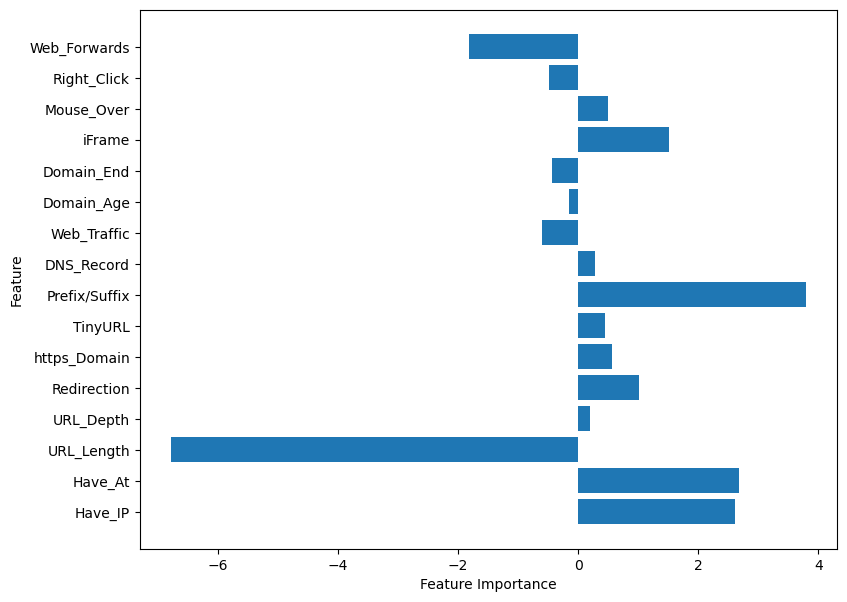

In [109]:
# Checking the coefficients (feature importances) in the model
plt.figure(figsize=(9, 7))
plt.barh(range(len(lr.coef_.flatten())), lr.coef_.flatten(), align='center')
plt.yticks(range(len(lr.coef_.flatten())), x_train.columns)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()


### 7.1 Naive Bayes

- #### Model Fitting

In [110]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train, y_train)
Y_pred_nb = nb.predict(x_test)

In [111]:
Y_pred_nb.shape

(2000,)

- #### Accuracy Check

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Calculate accuracy on the training set
acc_train_nb = accuracy_score(y_train, nb.predict(x_train))

# Calculate accuracy on the testing set
acc_test_nb = accuracy_score(y_test, Y_pred_nb)

In [113]:
#computing the accuracy of the model performance
print("Linear Regression: Accuracy on training Data: {:.1f}".format(acc_train_nb*100))
print("Linear Regression: Accuracy on training Data: {:.1f}".format(acc_train_nb*100))

Linear Regression: Accuracy on training Data: 79.2
Linear Regression: Accuracy on training Data: 79.2


- #### Storing results

In [114]:
storeResults('Linear Regression', acc_train_nb, acc_test_nb)

- #### Confusion Matrix and Classification Report

In [115]:
print(metrics.confusion_matrix(Y_pred_nb, y_test))
print(classification_report(y_test, Y_pred_nb))

[[987 411]
 [ 10 592]]
              precision    recall  f1-score   support

           0       0.71      0.99      0.82       997
           1       0.98      0.59      0.74      1003

    accuracy                           0.79      2000
   macro avg       0.84      0.79      0.78      2000
weighted avg       0.85      0.79      0.78      2000



### **7.2. Support Vector Machines**

In machine learning, support-vector machines (SVMs, also support-vector networks) are supervised learning models with associated learning algorithms that analyze data used for classification and regression analysis. Given a set of training examples, each marked as belonging to one or the other of two categories, an SVM training algorithm builds a model that assigns new examples to one category or the other, making it a non-probabilistic binary linear classifier.

- #### Model Fitting

In [116]:
#Support vector machine model
from sklearn.svm import SVC

# instantiate the model
svm = SVC(kernel='linear', C=1.0, random_state=12)
#fit the model
svm.fit(x_train, y_train)
Y_pred_svm = svm.predict(x_test)

In [117]:
Y_pred_svm.shape

(2000,)

- **Accuracy:**

In [118]:
#predicting the target value from the model for the samples
y_test_svm = svm.predict(x_test)
y_train_svm = svm.predict(x_train)

#computing the accuracy of the model performance
acc_train_svm = accuracy_score(y_train,y_train_svm)
acc_test_svm = accuracy_score(y_test,y_test_svm)

print("SVM: Accuracy on training Data: {:.1f}".format(acc_train_svm*100))
print("SVM : Accuracy on test Data: {:.1f}".format(acc_test_svm*100))

SVM: Accuracy on training Data: 80.3
SVM : Accuracy on test Data: 79.8


- **Storing the results:**

In [119]:
storeResults('SVM', acc_train_svm, acc_test_svm)

- #### Confusion matrix and Classsifcation Report

In [120]:
print(metrics.confusion_matrix(Y_pred_svm, y_test))
print(classification_report(y_test, Y_pred_svm))

[[974 380]
 [ 23 623]]
              precision    recall  f1-score   support

           0       0.72      0.98      0.83       997
           1       0.96      0.62      0.76      1003

    accuracy                           0.80      2000
   macro avg       0.84      0.80      0.79      2000
weighted avg       0.84      0.80      0.79      2000



- #### Feature Importance

In [152]:
# Assuming svm is your trained Support Vector Machine model
coefficients = svm.coef_.flatten()
feature_names = X.columns   

# Plot the coefficients
plt.figure(figsize=(10, 6))
plt.barh(range(len(coefficients)), coefficients, align='center')
plt.yticks(range(len(feature_names)), feature_names)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

### 7.3 K Neraest Neighbours
KNN is a simple machine learning algorithm used for classification and regression. It predicts the category or numerical value of a data point based on the majority or average of its 'k' nearest neighbors in the feature space. The choice of 'k' influences the model's sensitivity to local variations. Easy to understand but may not scale well with large datasets.

- #### Model Fitting

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Instantiating the KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)

# Fitting the model to the training data
knn.fit(x_train, y_train)

# Predicting the target values for the test set
Y_pred_knn = knn.predict(x_test.values)
Y_pred_knn.shape

- #### Accuracy 

In [122]:
#predicting the target value from the model for the samples
y_test_knn = knn.predict(x_test.values)
y_train_knn = knn.predict(x_train.values)

#computing the accuracy of the model performance
acc_train_knn = accuracy_score(y_train.values,y_train_knn)
acc_test_knn = accuracy_score(y_test.values,y_test_knn)

print("knn: Accuracy on training Data: {:.1f}".format(acc_train_knn*100))
print("knn : Accuracy on test Data: {:.1f}".format(acc_test_knn*100))

knn: Accuracy on training Data: 84.5
knn : Accuracy on test Data: 83.4


- #### Store Results

In [123]:
storeResults('KNN', acc_train_knn, acc_test_knn)

- #### Confusion matrix and Classsifcation Report

In [124]:
print(metrics.confusion_matrix(Y_pred_knn, y_test))
print(classification_report(y_test, Y_pred_knn))

[[905 241]
 [ 92 762]]
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       997
           1       0.89      0.76      0.82      1003

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000



### **7.4. Decision Tree Classifier**
 Decision trees are widely used models for classification and regression tasks. Essentially, they learn a hierarchy of if/else questions, leading to a decision. Learning a decision tree means learning the sequence of if/else questions that gets us to the true answer most quickly.
 
In the machine learning setting, these questions are called tests (not to be confused with the test set, which is the data we use to test to see how generalizable our model is). To build a tree, the algorithm searches over all possible tests and finds the one that is most informative about the target variable.

- #### Model fitting

In [125]:
# Decision Tree model 
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
tree = DecisionTreeClassifier(max_depth = 5)
# fit the model 
tree.fit(x_train, y_train)


DecisionTreeClassifier(max_depth=5)

In [126]:
#predicting the target value from the model for the samples
y_test_tree = tree.predict(x_test)
y_train_tree = tree.predict(x_train)

**Performance Evaluation:**

In [127]:
#computing the accuracy of the model performance
acc_train_tree = accuracy_score(y_train,y_train_tree)
acc_test_tree = accuracy_score(y_test,y_test_tree)

print("Decision Tree: Accuracy on training Data: {:.1f}".format(acc_train_tree*100))
print("Decision Tree: Accuracy on test Data: {:.1f}".format(acc_test_tree*100))

Decision Tree: Accuracy on training Data: 81.4
Decision Tree: Accuracy on test Data: 80.2


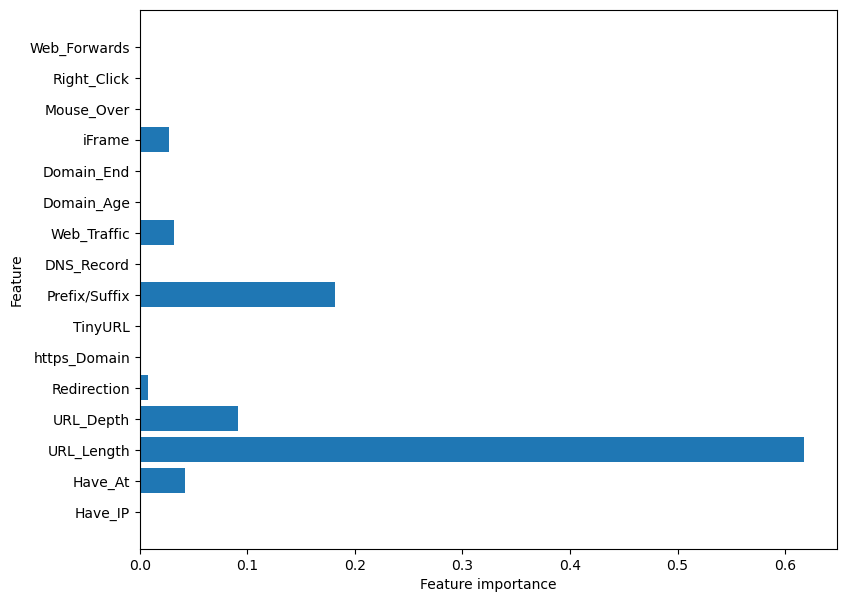

In [128]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = x_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), x_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

**Storing the results:**

In [129]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

### **7.5. Random Forest Classifier**
Random forests for regression and classification are currently among the most widely used machine learning methods.A random forest is essentially a collection of decision trees, where each tree is slightly different from the others. The idea behind random forests is that each tree might do a relatively good job of predicting, but will likely overfit on part of the data.

If we build many trees, all of which work well and overfit in different ways, we can reduce the amount of overfitting by averaging their results. To build a random forest model, you need to decide on the number of trees to build (the n_estimators parameter of RandomForestRegressor or RandomForestClassifier). They are very powerful, often work well without heavy tuning of the parameters, and don’t require scaling of the data.

- #### Model Fitting

In [130]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=20)

# fit the model 
forest.fit(x_train, y_train)

RandomForestClassifier(max_depth=20)

In [131]:
#predicting the target value from the model for the samples
y_test_forest = forest.predict(x_test)
y_train_forest = forest.predict(x_train)

- **Accuracy:**

In [132]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)

print("Random forest: Accuracy on training Data: {:.1f}".format(acc_train_forest*100))
print("Random forest: Accuracy on test Data: {:.1f}".format(acc_test_forest*100))

Random forest: Accuracy on training Data: 86.7
Random forest: Accuracy on test Data: 86.1


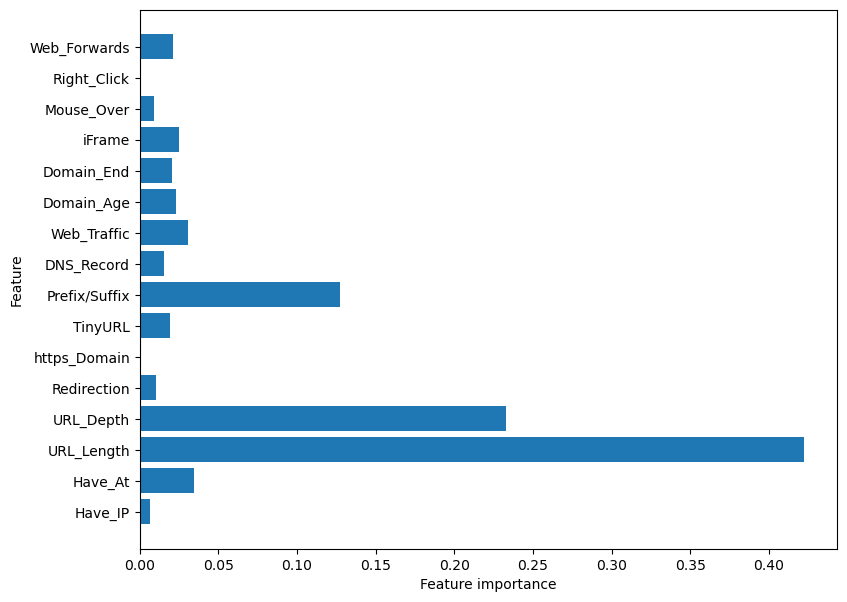

In [133]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = x_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), x_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

- **Storing the results:**

In [134]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', acc_train_forest, acc_test_forest)

### **7.6. Multilayer Perceptrons (MLPs): Deep Learning**
Multilayer perceptrons (MLPs) are also known as (vanilla) feed-forward neural networks, or sometimes just neural networks. Multilayer perceptrons can be applied for both classification and regression problems.

MLPs can be viewed as generalizations of linear models that perform multiple stages of processing to come to a decision.

- #### Model Fitting

In [135]:
# Multilayer Perceptrons model
from sklearn.neural_network import MLPClassifier

# instantiate the model
mlp = MLPClassifier(alpha=0.001, hidden_layer_sizes=([120,120,120]))

# fit the model 
mlp.fit(x_train, y_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=[120, 120, 120])

In [136]:
#predicting the target value from the model for the samples
y_test_mlp = mlp.predict(x_test)
y_train_mlp = mlp.predict(x_train)

- **Accuracy**

In [137]:
#computing the accuracy of the model performance
acc_train_mlp = accuracy_score(y_train,y_train_mlp)
acc_test_mlp = accuracy_score(y_test,y_test_mlp)

print("Multilayer Perceptrons: Accuracy on training Data: {:.1f}".format(acc_train_mlp*100))
print("Multilayer Perceptrons: Accuracy on test Data: {:.1f}".format(acc_test_mlp*100))

Multilayer Perceptrons: Accuracy on training Data: 86.7
Multilayer Perceptrons: Accuracy on test Data: 85.8


**Storing the results:**

In [138]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

### **7.7. XGBoost Classifier**
XGBoost is one of the most popular machine learning algorithms these days. XGBoost stands for eXtreme Gradient Boosting. Regardless of the type of prediction task at hand; regression or classification. XGBoost is an implementation of gradient boosted decision trees designed for speed and performance.

- #### Model Fitting

In [139]:
#XGBoost Classification model
from xgboost import XGBClassifier

# instantiate the model
xgb = XGBClassifier(learning_rate=0.4,max_depth=15)
#fit the model
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [140]:
#!pip install xgboost


In [141]:
#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(x_test)
y_train_xgb = xgb.predict(x_train)

- **Accuracy**

In [142]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.1f}".format(acc_train_xgb*100))
print("XGBoost : Accuracy on test Data: {:.1f}".format(acc_test_xgb*100))

XGBoost: Accuracy on training Data: 86.7
XGBoost : Accuracy on test Data: 86.3


- **Storing the results:**

In [143]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

## **8. Comparision of Models**
To compare the models performance, a dataframe is created. The columns of this dataframe are the lists created to store the results of the model.

In [145]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,    
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test})

# Multiply accuracy values by 100
results['Train Accuracy'] *= 100
results['Test Accuracy'] *= 100

results

,ML Model,Train Accuracy,Test Accuracy
0,Linear Regression,80.6,79.9
1,Linear Regression,79.2,79.0
2,SVM,80.3,79.8
3,KNN,84.6,83.4
4,Decision Tree,81.4,80.2
5,Random Forest,86.7,86.0
6,Multilayer Perceptrons,86.7,85.8
7,XGBoost,86.7,86.3


In [146]:
#Sorting the datafram on accuracy
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
7,XGBoost,86.7,86.3
5,Random Forest,86.7,86.0
6,Multilayer Perceptrons,86.7,85.8
3,KNN,84.6,83.4
4,Decision Tree,81.4,80.2
0,Linear Regression,80.6,79.9
2,SVM,80.3,79.8
1,Linear Regression,79.2,79.0


For the above comparision, it is clear that the MP works well with this dataset.

So, saving the model for future use.

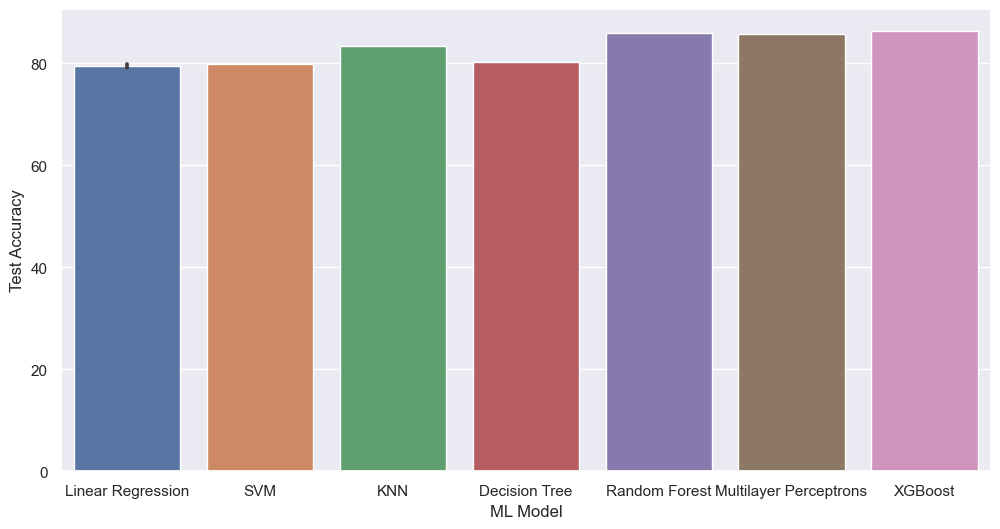

In [147]:
sns.set(rc={'figure.figsize':(12, 6)})
plt.xlabel("ML Model")
plt.ylabel("Accuracy")

sns.barplot(x='ML Model', y='Test Accuracy', data=results)

plt.show()

## Save model to file

In [148]:
import pickle
pickle.dump(xgb, open("PhishingWebsite_model.pickle.dat", "wb"))

**Testing the saved model:**

In [149]:
# load model from file
loaded_model = pickle.load(open("PhishingWebsite_model.pickle.dat", "rb"))
loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [150]:
# Sample data for numerical features

input_data = (0,0,1,2,0,0,0,0,0,1,0,1,0,0,1,0)
input_data_array = np.asarray(input_data)

input_data_reshaped = input_data_array.reshape(1, -1)

### <span style="color:red">Prediction</span>

In [151]:

prediction = loaded_model.predict(input_data_reshaped)

if prediction==1:
    target="Legitimate"
else:
    target = "Fake"

print("URL is of "+target + " website" )


URL is of Fake website


### <span style="color:green"> Consclusion:</span>
#### <span style="color:seagreen">My model is now predicting wheather a url is of a legitimate webiste or a phishing website</span>
**Website Status:** URL is of Fake website

**Test Accuracy:** 86.3%